# Q2. Distance Matrix Computation using `sklearn.metrics.pairwise_distances`

**Reference:** https://scikit-learn.org/stable/modules/generated/sklearn.metrics.pairwise_distances.html

In this notebook we demonstrate distance matrix computation using **two** distance calculation methods:

1. **Euclidean distance** (`metric='euclidean'`)
2. **Manhattan / City-block distance** (`metric='manhattan'`)

We use the survey dataset `lab2_data.xlsx` (placement/academic survey responses). A few numeric
features are selected and cleaned, after which `pairwise_distances` is used to compute an
$n \times n$ distance matrix between the students (rows).

In [1]:
import pandas as pd
import numpy as np
from sklearn.metrics import pairwise_distances
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 150)

## 1. Load the data

In [2]:
df = pd.read_excel('lab2_data.xlsx')
print(df.shape)
df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'lab2_data.xlsx'

## 2. Select and clean numeric features

Several survey columns contain messy text (e.g. `"20 LPA"`, `"10 lac"`, `"-"`, or fractions like
`0.8` instead of `80`). We write a small helper that extracts the numeric part from each entry and
rescales values so everything is on a comparable percentage/LPA scale before computing distances.

In [ ]:
def clean_percent(value):
    """Clean CIA%/GPA/Attendance style columns: strip text, rescale fractions (<=1) to 0-100."""
    if pd.isna(value):
        return np.nan
    s = str(value).strip()
    if s in ('-', ''):
        return np.nan
    try:
        num = float(s)
    except ValueError:
        return np.nan
    if num <= 1:
        num *= 100
    return num

def clean_package(value):
    """Clean package-expectation column: keep numeric LPA figures only."""
    if pd.isna(value):
        return np.nan
    s = str(value).strip().lower()
    if s in ('high', 'nothing much') or any(ch.isalpha() for ch in s.replace('lpa', '').replace('lac', '')):
        # sentence-style / non-numeric answers -> discard
        if not any(ch.isdigit() for ch in s):
            return np.nan
    num_str = ''.join(ch for ch in s if (ch.isdigit() or ch == '.'))
    if num_str == '':
        return np.nan
    num = float(num_str)
    if 'lac' in s:
        num = num  # 1 lac ~= 1 LPA order of magnitude, keep as-is
    if num > 1000:  # raw rupee figures e.g. 300000 -> convert to LPA
        num = num / 100000
    return num

features = pd.DataFrame({
    'extra_curricular_rating': df['Rate your contribution towards extra curricular activities'],
    'technical_competency_rating': df['Rate your technical competencies'],
    'package_expectation_lpa': df['What are your package expectations (LPA)'].apply(clean_package),
    'cia_percent': df['your CIA % of last semester'].apply(clean_percent),
    'gpa_last_sem': df['your GPA of last semester'].apply(clean_percent),
    'attendance_percent': df['Your maximum attendance % till last semester'].apply(clean_percent),
})

features = features.dropna().reset_index(drop=True)
print(features.shape)
features.head()

(142, 6)


,extra_curricular_rating,technical_competency_rating,package_expectation_lpa,cia_percent,gpa_last_sem,attendance_percent
0,3.0,4,20.0,60.0,62.0,77.0
1,3.0,2,11.0,67.0,60.0,97.0
2,3.0,4,5.0,80.0,80.0,99.0
3,3.0,3,20.0,65.0,76.0,96.0
4,3.0,2,40.0,79.0,69.0,98.0


## 3. Standardize features

Distance metrics like Euclidean and Manhattan are sensitive to feature scale, so we standardize
(z-score) the columns before computing distances. We'll work with a small sample of 10 students
so the resulting distance matrices are easy to read and visualize.

In [ ]:
from sklearn.preprocessing import StandardScaler

sample = features.sample(10, random_state=42).reset_index(drop=True)

scaler = StandardScaler()
X = scaler.fit_transform(sample)

labels = [f'Student {i}' for i in range(len(sample))]
sample

,extra_curricular_rating,technical_competency_rating,package_expectation_lpa,cia_percent,gpa_last_sem,attendance_percent
0,5.0,4,8.0,95.0,92.0,85.0
1,4.0,3,6.0,60.0,74.0,90.0
2,1.0,1,3.0,78.0,78.0,78.0
3,4.0,3,10.0,81.0,92.0,75.0
4,2.0,3,90.0,89.0,98.0,90.0
5,4.0,3,9.0,70.0,81.0,98.0
6,4.0,3,15.0,85.0,3.9,99.0
7,4.0,4,14.0,60.0,60.0,93.0
8,3.0,3,15.0,60.0,60.0,93.0
9,5.0,4,5.0,70.0,77.0,95.0


## 4. Method 1 — Euclidean Distance

`pairwise_distances(X, metric='euclidean')` computes the straight-line distance between every pair
of rows (students) in the feature space.

In [ ]:
euclidean_dist = pairwise_distances(X, metric='euclidean')

euclidean_df = pd.DataFrame(euclidean_dist, index=labels, columns=labels)
euclidean_df.round(2)

,Student 0,Student 1,Student 2,Student 3,Student 4,Student 5,Student 6,Student 7,Student 8,Student 9
Student 0,0.00,3.38,5.23,2.28,4.43,3.08,4.26,3.43,3.92,2.52
Student 1,3.38,0.00,4.10,2.72,4.60,1.37,3.65,1.42,1.13,1.81
Student 2,5.23,4.10,0.00,3.56,4.80,4.41,5.35,5.11,3.92,5.44
Student 3,2.28,2.72,3.56,0.00,4.22,3.18,4.68,3.41,3.30,3.20
Student 4,4.43,4.60,4.80,4.22,0.00,4.21,5.21,4.69,4.26,4.83
Student 5,3.08,1.37,4.41,3.18,4.21,0.00,3.27,1.81,1.59,1.53
Student 6,4.26,3.65,5.35,4.68,5.21,3.27,0.00,3.34,3.22,3.50
Student 7,3.43,1.42,5.11,3.41,4.69,1.81,3.34,0.00,1.46,1.42
Student 8,3.92,1.13,3.92,3.30,4.26,1.59,3.22,1.46,0.00,2.36
Student 9,2.52,1.81,5.44,3.20,4.83,1.53,3.50,1.42,2.36,0.00


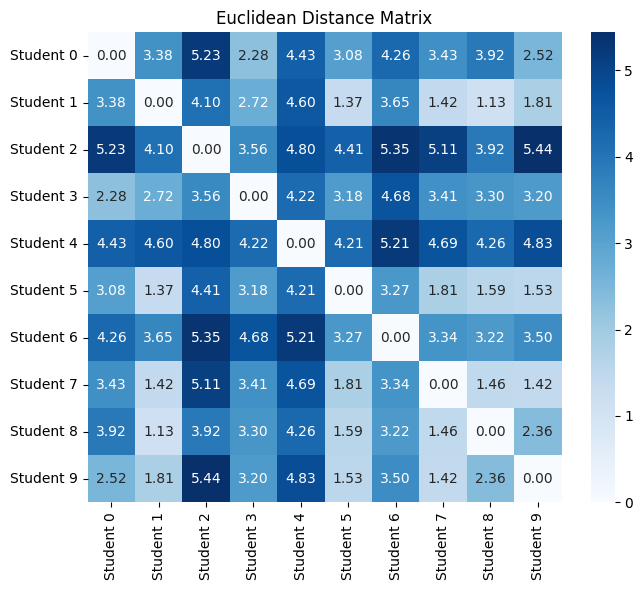

In [ ]:
plt.figure(figsize=(7,6))
sns.heatmap(euclidean_df, annot=True, fmt='.2f', cmap='Blues')
plt.title('Euclidean Distance Matrix')
plt.tight_layout()
plt.show()

## 5. Method 2 — Manhattan (City-block) Distance

`pairwise_distances(X, metric='manhattan')` computes the sum of absolute differences between
every pair of rows, i.e. distance measured along axes at right angles (like navigating city
blocks) rather than a straight line.

In [ ]:
manhattan_dist = pairwise_distances(X, metric='manhattan')

manhattan_df = pd.DataFrame(manhattan_dist, index=labels, columns=labels)
manhattan_df.round(2)

,Student 0,Student 1,Student 2,Student 3,Student 4,Student 5,Student 6,Student 7,Student 8,Student 9
Student 0,0.00,6.37,10.02,4.59,8.44,6.28,8.43,6.27,8.35,4.09
Student 1,6.37,0.00,8.25,4.57,8.43,2.27,6.35,2.47,2.14,3.68
Student 2,10.02,8.25,0.00,6.38,10.06,8.56,11.63,10.72,8.72,9.96
Student 3,4.59,4.57,6.38,0.00,7.80,4.40,7.13,6.72,6.39,6.36
Student 4,8.44,8.43,10.06,7.80,0.00,8.26,9.92,10.25,8.17,10.22
Student 5,6.28,2.27,8.56,4.40,8.26,0.00,4.63,3.71,3.38,2.75
Student 6,8.43,6.35,11.63,7.13,9.92,4.63,0.00,6.29,5.88,7.07
Student 7,6.27,2.47,10.72,6.72,10.25,3.71,6.29,0.00,2.08,2.95
Student 8,8.35,2.14,8.72,6.39,8.17,3.38,5.88,2.08,0.00,5.03
Student 9,4.09,3.68,9.96,6.36,10.22,2.75,7.07,2.95,5.03,0.00


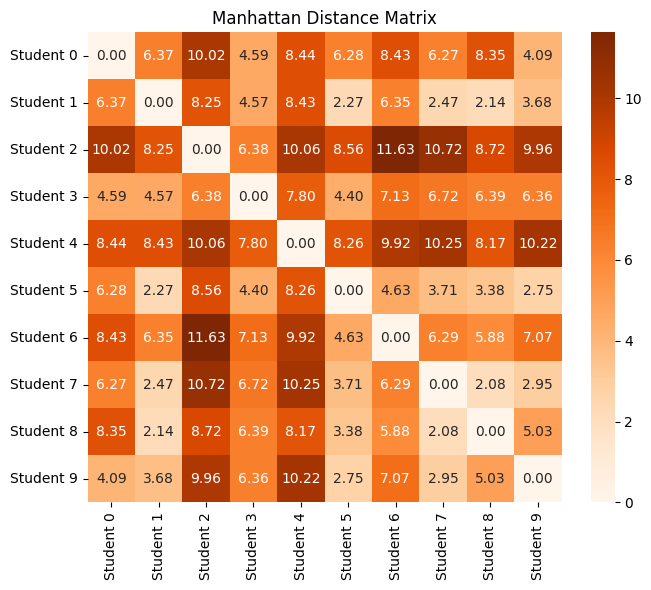

In [ ]:
plt.figure(figsize=(7,6))
sns.heatmap(manhattan_df, annot=True, fmt='.2f', cmap='Oranges')
plt.title('Manhattan Distance Matrix')
plt.tight_layout()
plt.show()

## 6. Comparing the two matrices

Both matrices are symmetric with a zero diagonal (each student's distance to itself is 0), but the
actual distance values differ because:

- **Euclidean distance** measures the straight-line ("as the crow flies") distance in feature
  space and is more sensitive to a few features with large differences (since differences are
  squared).
- **Manhattan distance** sums absolute differences across all features, treating each feature's
  contribution linearly, which makes it more robust to outliers in a single dimension.

In [ ]:
diff = (euclidean_df - manhattan_df)
print('Average difference between Manhattan and Euclidean distances:', round((manhattan_df.values - euclidean_df.values).mean(), 3))
diff.round(2)

Average difference between Manhattan and Euclidean distances: 2.835


,Student 0,Student 1,Student 2,Student 3,Student 4,Student 5,Student 6,Student 7,Student 8,Student 9
Student 0,0.00,-2.99,-4.79,-2.31,-4.01,-3.20,-4.17,-2.84,-4.43,-1.57
Student 1,-2.99,0.00,-4.15,-1.85,-3.83,-0.90,-2.71,-1.05,-1.01,-1.87
Student 2,-4.79,-4.15,0.00,-2.83,-5.26,-4.15,-6.28,-5.61,-4.80,-4.52
Student 3,-2.31,-1.85,-2.83,0.00,-3.58,-1.22,-2.45,-3.30,-3.09,-3.16
Student 4,-4.01,-3.83,-5.26,-3.58,0.00,-4.05,-4.70,-5.56,-3.91,-5.39
Student 5,-3.20,-0.90,-4.15,-1.22,-4.05,0.00,-1.36,-1.90,-1.79,-1.22
Student 6,-4.17,-2.71,-6.28,-2.45,-4.70,-1.36,0.00,-2.95,-2.66,-3.56
Student 7,-2.84,-1.05,-5.61,-3.30,-5.56,-1.90,-2.95,0.00,-0.61,-1.53
Student 8,-4.43,-1.01,-4.80,-3.09,-3.91,-1.79,-2.66,-0.61,0.00,-2.67
Student 9,-1.57,-1.87,-4.52,-3.16,-5.39,-1.22,-3.56,-1.53,-2.67,0.00


## 7. Conclusion

We used `sklearn.metrics.pairwise_distances` to compute pairwise distance matrices between
students using two different metrics — **Euclidean** and **Manhattan**. Both give an $n \times n$
matrix (here $10 \times 10$) quantifying dissimilarity between students based on their
extra-curricular rating, technical-competency rating, package expectation, CIA%, GPA, and
attendance%. Such distance matrices are the basis for clustering algorithms (e.g. K-Means,
Hierarchical Clustering) and nearest-neighbor methods.